# BH Seed Growth Demo
Run `MonteCarloBHSeedGrowth` with 10 experiments and plot the mass growth trajectories.

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.core import MonteCarloBHSeedGrowth
from gwGenealogy.utils import set_rcparams
import matplotlib.pyplot as plt
import numpy as np

set_rcparams()

lal.MSUN_SI != Msun


In [2]:
mc = MonteCarloBHSeedGrowth(v_esc=500, Z=0.005, chi_max=0.2, m_seed=10.0,
                           m_targets=[250], beta=4.0, kick_model='hlz',
                           n_pool=2000, seed=42)
print(mc)
result = mc.simulate(n_experiments=10, store_history=True, verbose=True)

MonteCarloBHSeedGrowth(v_esc=500.0, Z=0.005, chi_max=0.2, m_seed=10.0, kick=hlz, pool=982 BHs)


  1/10 done (P_ret=0.000)
  2/10 done (P_ret=0.000)
  3/10 done (P_ret=0.000)
  4/10 done (P_ret=0.000)
  5/10 done (P_ret=0.200)
  6/10 done (P_ret=0.167)
  7/10 done (P_ret=0.143)
  8/10 done (P_ret=0.125)
  9/10 done (P_ret=0.111)
  10/10 done (P_ret=0.100)


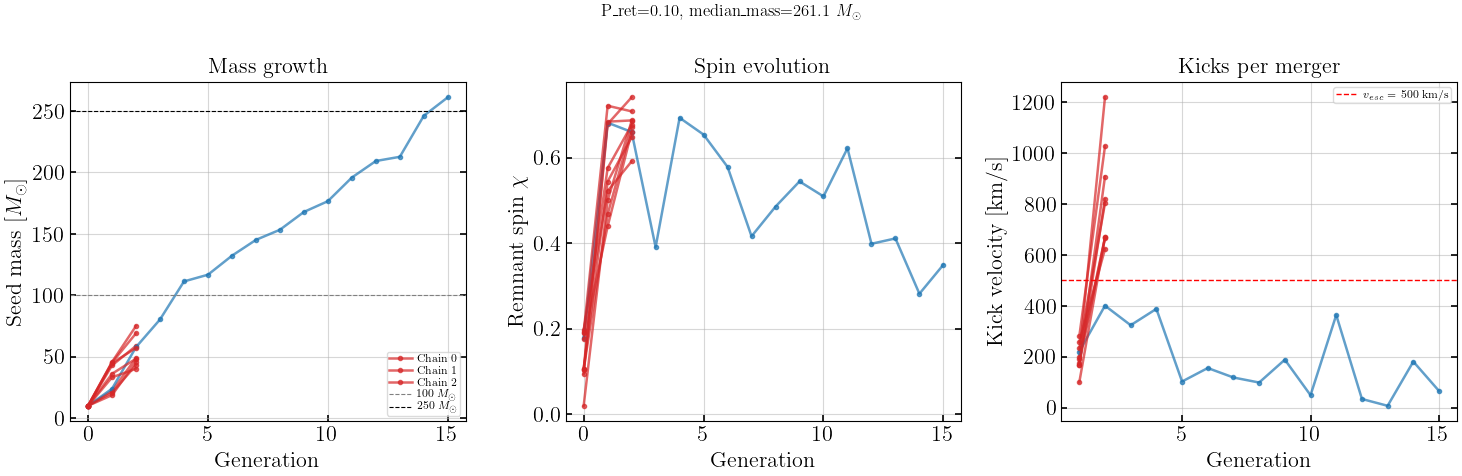

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mass growth trajectories
ax = axes[0]
for i, h in enumerate(result['histories']):
    gens = [0] + [s['generation'] for s in h]
    masses = [mc.m_seed] + [s['mass_after'] for s in h]
    label = f'Chain {i}' if i < 3 else None
    color = 'C0' if result['retained'][i] else 'C3'
    ax.plot(gens, masses, '-o', ms=3, alpha=0.7, color=color, label=label)
ax.axhline(100, ls='--', color='gray', lw=0.8, label='100 $M_\\odot$')
ax.axhline(250, ls='--', color='k', lw=0.8, label='250 $M_\\odot$')
ax.set_xlabel('Generation')
ax.set_ylabel('Seed mass [$M_\\odot$]')
ax.set_title('Mass growth')
ax.legend(fontsize=8)

# Spin evolution
ax = axes[1]
for i, h in enumerate(result['histories']):
    gens = [0] + [s['generation'] for s in h]
    spins = [h[0]['spin_before'] if h else 0] + [s['spin_after'] for s in h]
    color = 'C0' if result['retained'][i] else 'C3'
    ax.plot(gens, spins, '-o', ms=3, alpha=0.7, color=color)
ax.set_xlabel('Generation')
ax.set_ylabel('Remnant spin $\\chi$')
ax.set_title('Spin evolution')

# Kick vs escape velocity
ax = axes[2]
for i, h in enumerate(result['histories']):
    kicks = [s['v_kick'] for s in h]
    gens = [s['generation'] for s in h]
    color = 'C0' if result['retained'][i] else 'C3'
    ax.plot(gens, kicks, '-o', ms=3, alpha=0.7, color=color)
ax.axhline(mc.v_esc, ls='--', color='r', lw=1, label=f'$v_{{esc}}$ = {mc.v_esc:.0f} km/s')
ax.set_xlabel('Generation')
ax.set_ylabel('Kick velocity [km/s]')
ax.set_title('Kicks per merger')
ax.legend(fontsize=8)

fig.suptitle(f'P_ret={result["P_ret"]:.2f}, median_mass={result["median_mass"]:.1f} $M_\\odot$', fontsize=12)
plt.tight_layout()
plt.show()

## Extended run: max_generations=100
Let the seed keep merging well past the 250 Msun target.

In [4]:
mc2 = MonteCarloBHSeedGrowth(v_esc=150, Z=0.005, chi_max=1, m_seed=60.0,
                            m_targets=[5000], beta=0.0, kick_model='hlz',
                            n_pool=2000, max_generations=100, seed=42)
print(mc2)
result2 = mc2.simulate(n_experiments=50, store_history=True, verbose=True)

MonteCarloBHSeedGrowth(v_esc=150.0, Z=0.005, chi_max=1.0, m_seed=60.0, kick=hlz, pool=982 BHs)
  5/50 done (P_ret=0.000)
  10/50 done (P_ret=0.000)
  15/50 done (P_ret=0.000)
  20/50 done (P_ret=0.000)
  25/50 done (P_ret=0.000)
  30/50 done (P_ret=0.000)
  35/50 done (P_ret=0.000)
  40/50 done (P_ret=0.000)
  45/50 done (P_ret=0.000)
  50/50 done (P_ret=0.000)


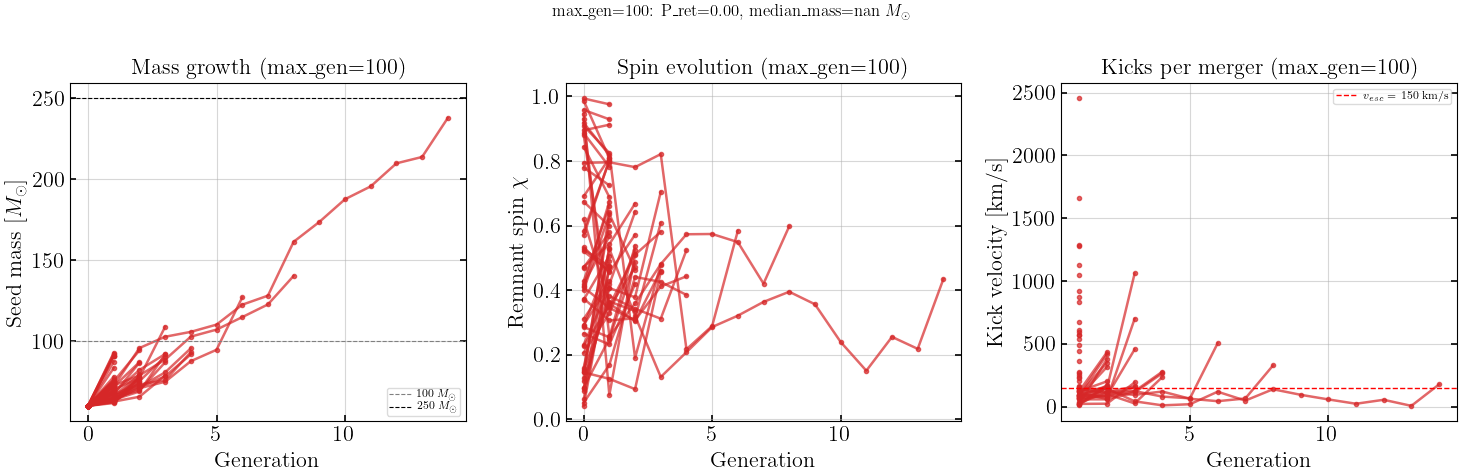

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Mass growth trajectories
ax = axes[0]
for i, h in enumerate(result2['histories']):
    gens = [0] + [s['generation'] for s in h]
    masses = [mc2.m_seed] + [s['mass_after'] for s in h]
    color = 'C0' if result2['retained'][i] else 'C3'
    ax.plot(gens, masses, '-o', ms=3, alpha=0.7, color=color)
ax.axhline(100, ls='--', color='gray', lw=0.8, label='100 $M_\\odot$')
ax.axhline(250, ls='--', color='k', lw=0.8, label='250 $M_\\odot$')
ax.set_xlabel('Generation')
ax.set_ylabel('Seed mass [$M_\\odot$]')
ax.set_title('Mass growth (max_gen=100)')
ax.legend(fontsize=8)

# Spin evolution
ax = axes[1]
for i, h in enumerate(result2['histories']):
    gens = [0] + [s['generation'] for s in h]
    spins = [h[0]['spin_before'] if h else 0] + [s['spin_after'] for s in h]
    color = 'C0' if result2['retained'][i] else 'C3'
    ax.plot(gens, spins, '-o', ms=3, alpha=0.7, color=color)
ax.set_xlabel('Generation')
ax.set_ylabel('Remnant spin $\\chi$')
ax.set_title('Spin evolution (max_gen=100)')

# Kick vs escape velocity
ax = axes[2]
for i, h in enumerate(result2['histories']):
    kicks = [s['v_kick'] for s in h]
    gens = [s['generation'] for s in h]
    color = 'C0' if result2['retained'][i] else 'C3'
    ax.plot(gens, kicks, '-o', ms=3, alpha=0.7, color=color)
ax.axhline(mc2.v_esc, ls='--', color='r', lw=1, label=f'$v_{{esc}}$ = {mc2.v_esc:.0f} km/s')
ax.set_xlabel('Generation')
ax.set_ylabel('Kick velocity [km/s]')
ax.set_title('Kicks per merger (max_gen=100)')
ax.legend(fontsize=8)

fig.suptitle(f'max_gen=100: P_ret={result2["P_ret"]:.2f}, median_mass={result2["median_mass"]:.1f} $M_\\odot$', fontsize=12)
plt.tight_layout()
plt.show()

## Escape velocity sweep with run_grid
Reuse the same 1G pool and sweep P_ret over a range of v_esc values.

In [6]:
mc3 = MonteCarloBHSeedGrowth(v_esc=100, Z=0.005, chi_max=0.2, m_seed=10.0,
                            m_targets=[250], beta=4.0, kick_model='hlz',
                            n_pool=2000, seed=42)
v_esc_arr = np.linspace(50, 600, 15)
grid = mc3.simulate_grid(v_esc_arr, n_experiments=50, verbose=True)

  v_esc=50 km/s: P_ret=0.000
  v_esc=89 km/s: P_ret=0.000
  v_esc=129 km/s: P_ret=0.000
  v_esc=168 km/s: P_ret=0.000
  v_esc=207 km/s: P_ret=0.000


  v_esc=246 km/s: P_ret=0.000
  v_esc=286 km/s: P_ret=0.040
  v_esc=325 km/s: P_ret=0.040


  v_esc=364 km/s: P_ret=0.040
  v_esc=404 km/s: P_ret=0.080


  v_esc=443 km/s: P_ret=0.100
  v_esc=482 km/s: P_ret=0.120


  v_esc=521 km/s: P_ret=0.140
  v_esc=561 km/s: P_ret=0.220


  v_esc=600 km/s: P_ret=0.220


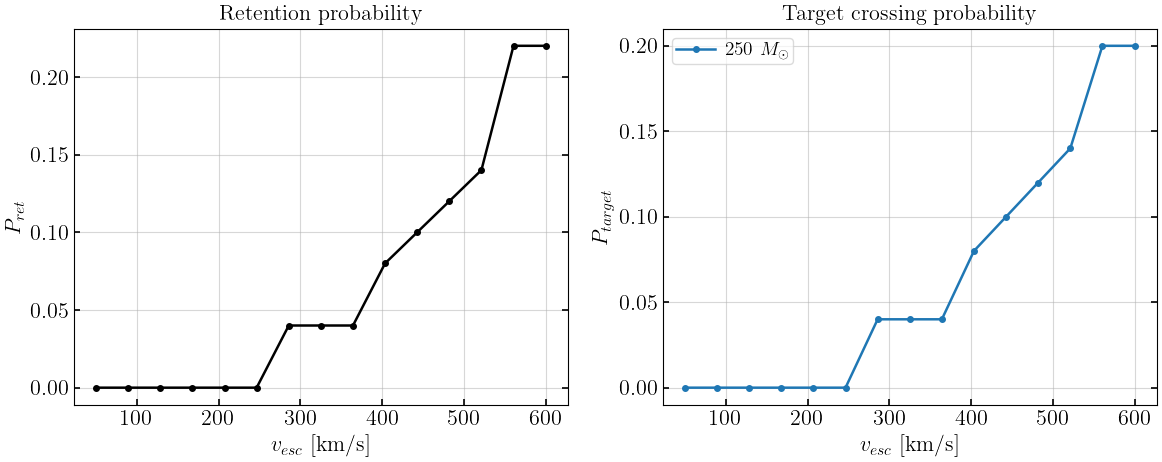

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# P_ret vs v_esc
ax = axes[0]
ax.plot(grid['v_esc_values'], grid['P_ret'], 'k-o', ms=4)
ax.set_xlabel('$v_{esc}$ [km/s]')
ax.set_ylabel('$P_{ret}$')
ax.set_title('Retention probability')

# P_target vs v_esc
ax = axes[1]
for mt in mc3.m_targets:
    ax.plot(grid['v_esc_values'], grid['P_target'][mt], '-o', ms=4, label=f'{mt:.0f} $M_\\odot$')
ax.set_xlabel('$v_{esc}$ [km/s]')
ax.set_ylabel('$P_{target}$')
ax.set_title('Target crossing probability')
ax.legend()

plt.tight_layout()
plt.show()

## Evolving escape velocity

Clusters lose mass over time, so $v_{esc}$ decreases. With `evolve_v_esc=True`,
the escape velocity decays as $v_{esc}(g) = v_0 \, g^{\alpha}$ where $\alpha = -0.35$
by default. Compare constant vs evolving $v_{esc}$.

In [8]:
common_kw = dict(v_esc=1000, Z=0.005, chi_max=0.2, m_seed=10.0,
                 m_targets=[2500], beta=4.0, kick_model='hlz',
                 n_pool=2000, max_generations=100, seed=42)

mc_const = MonteCarloBHSeedGrowth(evolve_v_esc=False, **common_kw)
mc_evolve = MonteCarloBHSeedGrowth(evolve_v_esc=True, **common_kw)
print(mc_const)
print(mc_evolve)

n_exp = 50
res_const = mc_const.simulate(n_experiments=n_exp, store_history=True, verbose=True)
print()
res_evolve = mc_evolve.simulate(n_experiments=n_exp, store_history=True, verbose=True)

MonteCarloBHSeedGrowth(v_esc=1000.0, Z=0.005, chi_max=0.2, m_seed=10.0, kick=hlz, pool=982 BHs)
MonteCarloBHSeedGrowth(v_esc=1000.0*g^(-0.35), Z=0.005, chi_max=0.2, m_seed=10.0, kick=hlz, pool=982 BHs)


  5/50 done (P_ret=0.800)
  10/50 done (P_ret=0.700)


  15/50 done (P_ret=0.667)
  20/50 done (P_ret=0.650)


  25/50 done (P_ret=0.720)


  30/50 done (P_ret=0.767)


...

  45/50 done (P_ret=0.733)


  50/50 done (P_ret=0.740)

  5/50 done (P_ret=0.600)
  10/50 done (P_ret=0.300)


  15/50 done (P_ret=0.333)
  20/50 done (P_ret=0.250)
  25/50 done (P_ret=0.240)


  30/50 done (P_ret=0.300)
  35/50 done (P_ret=0.314)
  40/50 done (P_ret=0.300)


  45/50 done (P_ret=0.289)
  50/50 done (P_ret=0.300)


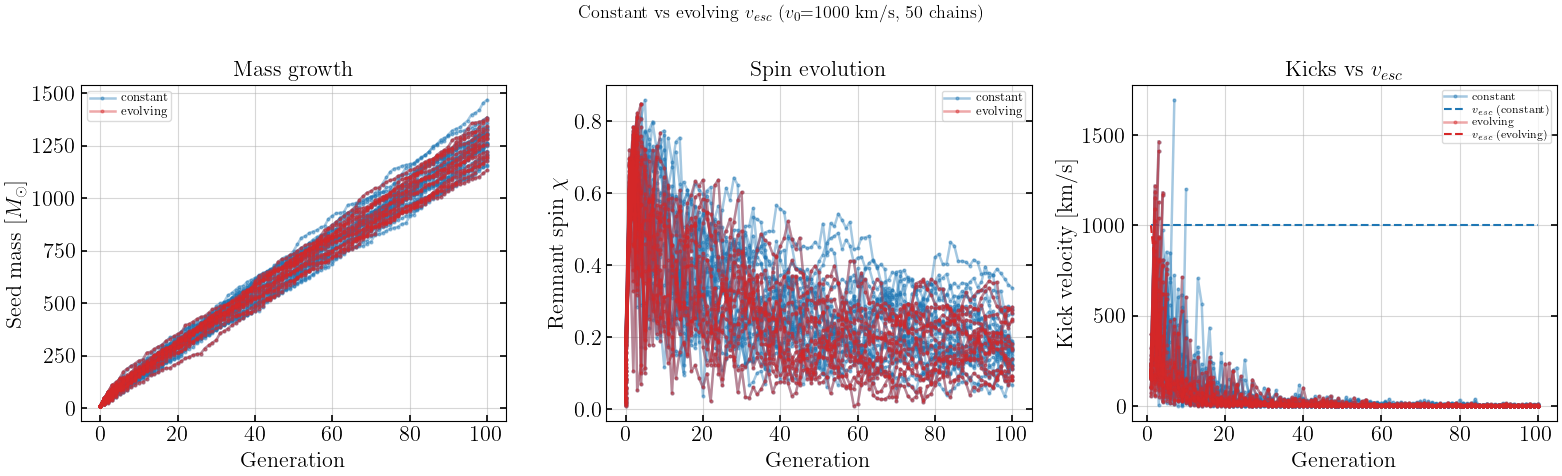

                       constant   evolving
P_ret                     0.740      0.300
P_target(2500)            0.000      0.000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for res, mc, label, color in [(res_const, mc_const, 'constant', 'C0'),
                                (res_evolve, mc_evolve, 'evolving', 'C3')]:
    for i, h in enumerate(res['histories']):
        gens = [0] + [s['generation'] for s in h]
        masses = [mc.m_seed] + [s['mass_after'] for s in h]
        lbl = label if i == 0 else None
        axes[0].plot(gens, masses, '-o', ms=2, alpha=0.4, color=color, label=lbl)

    for i, h in enumerate(res['histories']):
        gens = [0] + [s['generation'] for s in h]
        spins = [h[0]['spin_before'] if h else 0] + [s['spin_after'] for s in h]
        lbl = label if i == 0 else None
        axes[1].plot(gens, spins, '-o', ms=2, alpha=0.4, color=color, label=lbl)

    for i, h in enumerate(res['histories']):
        kicks = [s['v_kick'] for s in h]
        v_escs = [s['v_esc'] for s in h]
        gens = [s['generation'] for s in h]
        lbl = label if i == 0 else None
        axes[2].plot(gens, kicks, '-o', ms=2, alpha=0.4, color=color, label=lbl)
        if i == 0:
            axes[2].plot(gens, v_escs, '--', color=color, lw=1.5,
                         label=f'$v_{{esc}}$ ({label})')

axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Seed mass [$M_\\odot$]')
axes[0].set_title('Mass growth')
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Generation')
axes[1].set_ylabel('Remnant spin $\\chi$')
axes[1].set_title('Spin evolution')
axes[1].legend(fontsize=9)

axes[2].set_xlabel('Generation')
axes[2].set_ylabel('Kick velocity [km/s]')
axes[2].set_title('Kicks vs $v_{esc}$')
axes[2].legend(fontsize=8)

fig.suptitle(f'Constant vs evolving $v_{{esc}}$ ($v_0$={common_kw["v_esc"]} km/s, {n_exp} chains)',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'':20s} {'constant':>10s} {'evolving':>10s}")
print(f"{'P_ret':20s} {res_const['P_ret']:10.3f} {res_evolve['P_ret']:10.3f}")
for mt in common_kw['m_targets']:
    print(f"{'P_target('+str(mt)+')':20s} {res_const['P_target'][mt]:10.3f} {res_evolve['P_target'][mt]:10.3f}")

In [10]:
v_esc_arr = np.linspace(50, 600, 15)
grid_const = mc_const.simulate_grid(v_esc_arr, n_experiments=50, verbose=True)
print()
grid_evolve = mc_evolve.simulate_grid(v_esc_arr, n_experiments=50, verbose=True)

  v_esc=50 km/s: P_ret=0.000
  v_esc=89 km/s: P_ret=0.000
  v_esc=129 km/s: P_ret=0.000
  v_esc=168 km/s: P_ret=0.000
  v_esc=207 km/s: P_ret=0.000


  v_esc=246 km/s: P_ret=0.000
  v_esc=286 km/s: P_ret=0.040


  v_esc=325 km/s: P_ret=0.040
  v_esc=364 km/s: P_ret=0.040


  v_esc=404 km/s: P_ret=0.080


  v_esc=443 km/s: P_ret=0.100


...

  v_esc=600 km/s: P_ret=0.220

  v_esc=50 km/s: P_ret=0.000
  v_esc=89 km/s: P_ret=0.000
  v_esc=129 km/s: P_ret=0.000
  v_esc=168 km/s: P_ret=0.000
  v_esc=207 km/s: P_ret=0.000


  v_esc=246 km/s: P_ret=0.000
  v_esc=286 km/s: P_ret=0.000
  v_esc=325 km/s: P_ret=0.000
  v_esc=364 km/s: P_ret=0.000


  v_esc=404 km/s: P_ret=0.020
  v_esc=443 km/s: P_ret=0.020


  v_esc=482 km/s: P_ret=0.040
  v_esc=521 km/s: P_ret=0.040


  v_esc=561 km/s: P_ret=0.040
  v_esc=600 km/s: P_ret=0.040


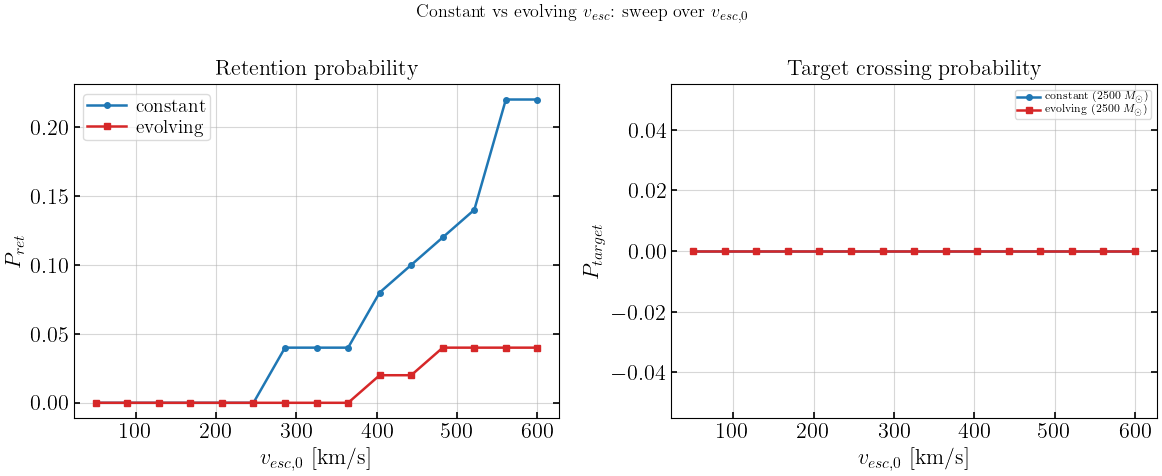

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grid_const['v_esc_values'], grid_const['P_ret'], 'C0-o', ms=4, label='constant')
axes[0].plot(grid_evolve['v_esc_values'], grid_evolve['P_ret'], 'C3-s', ms=4, label='evolving')
axes[0].set_xlabel('$v_{esc,0}$ [km/s]')
axes[0].set_ylabel('$P_{ret}$')
axes[0].set_title('Retention probability')
axes[0].legend()

for mt in common_kw['m_targets']:
    axes[1].plot(grid_const['v_esc_values'], grid_const['P_target'][mt], 'C0-o', ms=4,
                 label=f'constant ({mt} $M_\\odot$)')
    axes[1].plot(grid_evolve['v_esc_values'], grid_evolve['P_target'][mt], 'C3-s', ms=4,
                 label=f'evolving ({mt} $M_\\odot$)')
axes[1].set_xlabel('$v_{esc,0}$ [km/s]')
axes[1].set_ylabel('$P_{target}$')
axes[1].set_title('Target crossing probability')
axes[1].legend(fontsize=8)

fig.suptitle('Constant vs evolving $v_{esc}$: sweep over $v_{esc,0}$', fontsize=13)
plt.tight_layout()
plt.show()